-----
# AM10 - Computing for Science and Engineering - Module 3

## Lab 11
-----

### Learning objectives:

- Implementing Monte Carlo integration (rejection method and averaging samples)

- Applications of random numbers

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Implementing Monte Carlo integration (rejection)

Let's begin by continuting from the lecture and integrate $x^3$ from $x=0$ to $x=1$.

As we usually do, we will implement a Python function.

----------------------

Start by defining a Python function, let's call it `fofx` for consistency, that outputs the result of the expression $x^3$. Since you have done this multiple times by now, the code is already provided below.

In [3]:
# Defining the function for x^3
def fofx(x):
    y = x**3
    return y

The code below is directly copied from the part of the Lecture 11 where you integrated $x^3$. We want to use some of this code and define a function `mcint1` that will output the integral of a mathematical expression. The inputs for `mcint1` should be:
1. A python function representing the mathematical expression to be integrated (`func`)
2. The number of points (`nump`) to use

Let's work on this togehter.

In [2]:
#---------------------
# CODE FROM LECTURE 11
#---------------------

# Example 5: calculate integral of x^3 from x=0 to 1.

def fofx(x):
    return x**3

Mmax=6
Nsav=np.zeros(Mmax)
intsav=np.zeros(Mmax)

for m in range(Mmax):
    
    intsum=0.0
    N=10**(m+1)
    for n in range(N):
        x=np.random.rand()
        y=np.random.rand()
        if (y<fofx(x)):
            intsum=intsum+1.0

    Nsav[m]=m+1
    intsav[m]=intsum/N
    print(N,intsum/N)

10 0.3
100 0.2
1000 0.256
10000 0.2498
100000 0.25157
1000000 0.250683


In [4]:
def mcint1(func, nump):
    '''
        Input:
            func: Python function representing the mathematical function to be integrated
            nump: number of random samples to draw for Monte Carlo
        Output:
            intfin: value of the integral
    '''
    intsum = 0
    for n in range(nump):
        x = np.random.rand()
        y = np.random.rand()
        if (y < func(x)):
            intsum = intsum + 1.0
    intfin = intsum / nump
    
    return intfin

Now let's test the function by integrating $x^3$ from $x=0$ to $x=1$ using 10000 points.

In [7]:
nump = 10000
int1 = mcint1(fofx, nump)
print('Monte Carlo =', int1, 'Theoretical =', 0.25)

Monte Carlo = 0.2429 Theoretical = 0.25


----------

### *Breakout Room Discussion (8 mins)*

What if we wanted to integrate $x^3$ from $x=0$ to $x=3$? Would `mcint1` work? Why or why not? 
If you understand why `mcint1` fails, go ahead and discuss how you would fix it.

----------

### *Notes*

Clearly, the function `mc_int1` above will not work. 

Let's review how our Monte Carlo integration code actually works. The principle behind the above implementation is called the *rejection method*. By rejecting the random samples that do not lie under our curve and counting how many actually do, we are able to find the probability of picking a point under the curve, which is related to the area under the curve. (See also Section 11.4 and Figure 11.3 from the Lecture notes). 

The probability, $p$ that a point picked at random lies under the curve of our function is given by the ratio of the area under the curve, $A_c$, and the area of the box, $A_t$, enclosing the range of our samples. In addition, we can also approximate the probability by randomly sampling point and finding how many under the curve, $N_c$, divided by the total number of random points picked, $N_t$.

$$p = \frac{A_c}{A_t} = \frac{N_c}{N_t}$$

So, by rearranging the above expression, we can find the area under the curve, *i.e.*, the integral of our function, as follows.

$$A_c = A_t\frac{N_c}{N_t}$$

Now, take a look at the code for `mcint1` again. 

You will notice that `intsum / nump` is the ratio of number of points under the curve and total number of samples. However, we are not taking into account the area of the box ($A_t$) that encloses the ranges of the sampled points (becasue when integrating from $x=0$ to $x=1$ the area of this box is 1, so it doesn't matter for that particular case). Let's try to fix `mcint1`.

### *Main Room Exercise 1*

Modify the function `mcint1` (call it `mcint2`) such that you can integrate a given function in an expanded range beyond $0<x<1$. Besides the inputs of `func` and `nump`, `mcint2` should also have inputs for the range in which the integration is desired. Change the ranges of the uniform random numbers based on this range and update the final output `intsum` appropriately. Then, test the function by integrating $x^3$ from $x=0$ to $x=3$. The analytical result is 20.25.

In [8]:
def mcint2(func, nump, a, b):
    '''
        Input:
            func: Python function representing the mathematical function to be integrated
            nump: number of random samples to draw for Monte Carlo
            a: minimum of range
            b: maximum of range
        Output:
            intfin: value of the integral
    '''
    intsum = 0
    d = np.maximum(func(a), func(b))
    for n in range(nump):
        x = a + np.random.rand() * (b - a)
        y = np.random.rand() * d
        if (y < func(x)):
            intsum = intsum + 1.0
    intfin = (b - a) * d *intsum / nump
    
    return intfin

In [10]:
a = 0
b = 3
nump = 10000

int2 = mcint2(fofx, nump, a, b)
print('Monte Carlo =', int2, 'Theoretical =', 20.25)

Monte Carlo = 20.3391 Theoretical = 20.25


Now, what if we want to integrate in the range $x=-2$ to $x=3$? Try it... (The analytical result is 16.25)

`mcint2` will not give you the correct answer. Why is that? 

The error in our code for `mcint2` comes from the fact that we are not correctly sampling along the y axis. We are only taking into consideration random points between 0 and the maximum of the function at the extreme values of the given interval. This method will also fais if we have a function that peaks somewhere in between the interval.

As you might realize making this code based on rejection general enough to work in any arbitrary range for any given function will need a lot more work. 

In the exercises below, we will look at another way to iumplement Monte Carlo integration, this time by averaging our random samples. This method is perhaps less intuitive than rejection however, is easier to implement and is more robust.

## Implementing Monte Carlo integration (averaging random samples)

This idea is similar to the geometric interpretation of numerical integration (see Section 7.2 of Lecture notes). The integral of the function can be thought of as the sum of small rectangular sections with the height equal to the value of the function and the width equal to the full range divided by the number of segments.

\begin{equation}
\int_a^bf(x)dx \approx \frac{b-a}{N}\sum_{i=0}^{N-1}f(x_i).
\end{equation}

The main difference between this geometric interpretation and the implementation of the Monte Carlo integration is that the variables $x_i$ are randomly picked. 

Let's implement this in the exercise below.

-------

### *Main Room Exercise 2*

Write a function (let's just call it `mcint_1d`) to implement the Monte Carlo method (averaging random samples) to integrate any given function and range. Keep the same input and output as `mcint2`. Then, test the function by integrating $x^3$ from $x=-2$ to $x=3$. The analytically solved result is 16.25.

In [12]:
def mcint_1d(func, nump, a, b):
    '''
        Input:
            func: Python function representing the mathematical function to be integrated
            nump: number of random samples to draw for Monte Carlo
            a: minimum of range
            b: maximum of range
        Output:
            intfin: value of the integral
    '''
    intsum = 0
    for i in range(nump):
        x = a + np.random.rand() * (b - a)
        intsum = intsum + func(x)
    intfin = intsum * (b - a) / nump
    return intfin

In [15]:
a = -2
b = 3

nump = 1000000

int3 = mcint_1d(fofx, nump, a, b)
print('Monte Carlo =', int3, 'Theoretical =', 16.25)

Monte Carlo = 16.252943402337547 Theoretical = 16.25


## Extenting Monte Carlo integration to multi-variable functions

A big advantage of Monte Carlo integration is its use for multi-variable integrals. 

Let's consider the simple numerical integration using summation from Lab 06. If we wanted to extend our code to a two dimentional function then we would have to write two `for` loops. One to sum over the function at all values of $x$ and another one inside it to sum over all values of $y$. The psuedocode would look as follows:

```
for element yj in the array of y values
    for element xi in the array of x values
        take the sum of f(xi, yj)
integral is range of x times range of y times the sum divided by total number of points
```

Let's discuss how we would extend the Monte Carlo integration function `mcint_1d` to allow integrating a two dimentional function and implement it in code. We will test it by integrating the following function
$$g(x, y) = \sin(x)\sin(y)$$
in the range $0$ to $\pi$ for both variables $x$ and $y$.

### *Notes*
Using randomly sampled points at which the function is evaluated, only one `for` loop suffices. The psuedocode for a 2D Monte Carlo integration function would look as follows:

```
for point i in the range of total points N
    pick point xi using random numbers in the range ax, bx
    pick point yi using random numbers in the range ay, by
    take the sum of f(xi, yi)
integral is range of x times range of y times the sum divided by total number of points
```

Now, imagine how much of a difference this reduction in number of `for` loops makes as the number of variables increases!

Let's implement a function that performs a 2D Monte Carlo integration in the exercise below and integrate a 2D Gaussian.

-------------

### 2D integration using the Monte Carlo method

Let's modify the code from `mcint_1d` (call the new function `mcint_2d`) to implement 2D Monte Carlo integration.

In [16]:
def mcint_2d(func, nump, ax, bx, ay, by):
    '''
        Input:
            func: Python function representing the mathematical function to be integrated
            nump: number of random samples to draw for Monte Carlo
            ax: minimum of range along x
            bx: maximum of range along x
            ay: minimum of range along y
            by: maximum of range along y            
        Output:
            intfin: value of the integral
    '''
    intsum = 0
    for i in range(nump):
        x = ax + np.random.rand() * (bx - ax)
        y = ay + np.random.rand() * (by - ay)
        intsum = intsum + func(x, y)
    intfin = intsum * (bx - ax) * (by - ay) / nump
    
    return intfin

In [17]:
def gofxy(x, y):
    return np.sin(x) * np.sin(y)

In [18]:
ax = 0
bx = np.pi
ay = 0
by = np.pi

nump = 10000

int4 = mcint_2d(gofxy, nump, ax, bx, ay, by)
print('Monte Carlo =', int4, 'Theoretical =', 4)

Monte Carlo = 4.007922094544591 Theoretical = 4


-------

## Application of Random Numbers: A simple simulation of radioactive decay

Radioactive decay is a true random process! For any given radioactive atom (or rather nuclei), i.e, at the scale of a single atom, the time at which it will decay is purely random. Meaning, it is impossible to predict when a particular radioactive atom will decay. However, at the macro scale, i.e., when a large collection of radioacive atoms are considered, the probability of decay in a time $\Delta t$ is a constant and is given by
$$p = \alpha \Delta t$$
(We will assume that $\alpha\Delta t << 1$ for simplicity.)

This above rule can be written as a differential equation as shown below.
$$\frac{dN}{dt} = -\alpha N$$ 
which states that the rate of decay of a population of radioactive atoms is proportional to the number of atoms $N$ with the decay constant $\alpha$ being the constant of proportionality. This ODE can be solved analytically and the solution is as shown below.
$$N = N_0\mathrm{e}^{-\alpha t}$$
where $N_0$ is the initial number of radioactive atoms in the population. 

Let's look at how we can simulation this stochastic process. Say, we start with $N$ radioactive atoms and the decay constant $\alpha$. Also, let's choose a value for $\Delta t$.
Then, at a given time for a particular atom, we can draw a random number $r$ and check whether the probability of decay ($p = \alpha \Delta t$), $p > r$, if so, then we can assume that that atom has decayed and we remove it from the population, if not, then we move to the next atom.

Here's some pseudocode for the above:

```
loop over time with increment of dt
    loop over number of undecayed atoms, N
        draw random number r from uniform distribution in [0,1)
        check if p > r
            if yes reduce number of undecayed atoms by 1
plot N vs time
```

-------
### *Breakout Room Discussion (10 mins)*

Now, discuss with your group and implement the code for the pseudocode above. 

*Pick a random number between 1 and the number of people in your group to decide who shares the screen and types the code.*

Choose the following constants: $N_0 = 100$, $\alpha=0.01$, $\Delta t=1$, $t_{max}=200$

----------

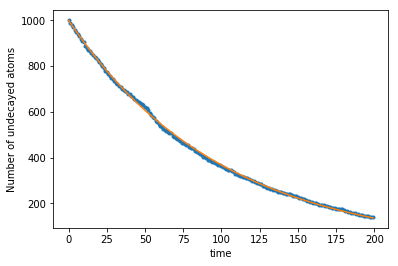

In [22]:
# Define the constants
n0 = 1000
alpha = 0.01
dt = 1
p = alpha * dt

# create arrays for time and number of undecayed atoms
tmax = 200
time = np.arange(0, tmax, dt)
n_sim = np.zeros(len(time))


# create array with the theoretical number of undecayed atoms as a function of time
n_theo = n0 * np.exp(-alpha * time)

# loop over time
for t in range(tmax):

    # assign the value of number of atoms left 
    n_sim[t] = n0
    # loop over the number of atoms left
    for n in range(n0):
        # draw a random number between 0 and 1 with a uniform distribution
        r = np.random.rand()
        # check if p > r
        if p > r:
            # reduce the number of undecayed atoms by 1
            n0 = n0 - 1 
            # check if number of undecayed atoms becomes negative
            if n0 < 0:
                break


# plot the simulation and theoretical result
plt.plot(time, n_sim, '.')
plt.plot(time, n_theo, '-')
plt.xlabel('time')
plt.ylabel('Number of undecayed atoms')
plt.show()